# Lancoz Algorithm, Ground-State: Heisenberg model (J1-J1 model (J = 0))

> **Code basé sur le tutoriel officiel de NetKet :**
> G. Carleo et F. Vicentini, *Ground-State: Heisenberg model*, NetKet Tutorials. 
> [En ligne]. Disponible : [https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html](https://netket.readthedocs.io/en/latest/tutorials/gs-heisenberg.html)

In [2]:
import tqdm as tqdm
import netket as nk
import time
import numpy as np
from tqdm import tqdm
import os
import sys
import json

/Users/user/Desktop/EPFL/MA2/TPIV/project-tp/.env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can load logged data with nk.utils.history.HistoryDict.from_file(data.log).

In [3]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.lanczos_krylov import Krylov_method_with_bootstrap
from src.utils import *
from src.plot.plotlib import *

In [4]:
verbose = True

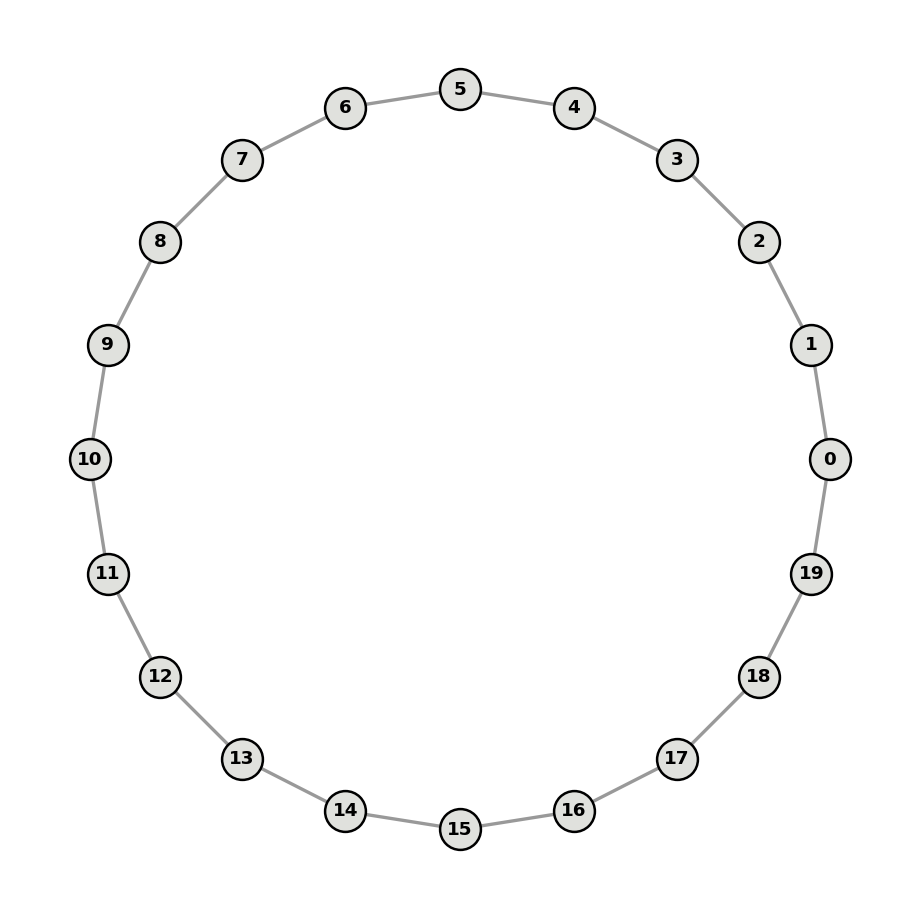

In [5]:
# Defining the Hamiltonian
L = 20
graph = nk.graph.Hypercube(length=L, n_dim=1, pbc=True)
hi = nk.hilbert.Spin(s=0.5, total_sz=0, N=graph.n_nodes)
ha = 0.25 * nk.operator.Heisenberg(hilbert=hi, graph=graph) # 0.25 = 1/4 : pour passer d'une description en matrices de Pauli en matrice spin
plot_netket_graph(graph)

In [25]:
# Exact Diagonalization
evals = nk.exact.lanczos_ed(ha, compute_eigenvectors=False)
exact_gs_energy = evals[0]
if verbose:
    print("The exact ground-state energy is E0=", exact_gs_energy)

The exact ground-state energy is E0= -8.904386529876458


In [17]:
# hyperparameters 
diag_shift = 1e-4           # The diagonal regularization parameter
learning_rate = 1e-2        # learning rate
n_samples = 2048            # number of samples (aug : pour avoir des stats physiques), 4096
n_iter = 100                # number of iterations # 600
alpha = 1                   # feature density. Number of features equal to alpha * input.shape[-1]
num_it = 1000               # number of iterations for the Krylov method

# data directory
data_file = f"../../datas/datas_krylov_iter_{n_iter}"
dir_init = data_file + "/RBM_init"
if not os.path.exists(data_file):
    os.makedirs(data_file)
    print(f"Le dossier '{data_file}' vient d'être créé.")
else:
    print(f"Le dossier '{data_file}' existe déjà.")

hyperparameters = {
    "data_file": data_file,
    "dir_init": dir_init,
    "diag_shift": diag_shift,
    "learning_rate": learning_rate,
    "n_samples": n_samples,
    "n_iter": n_iter,
    "feature_density_alpha": alpha,
    "num_it": num_it,
    "L": L
}
json_path = os.path.join(data_file, "hyperparameters.json")

with open(json_path, 'w') as f:
    json.dump(hyperparameters, f, indent=4) 

print(f"Paramètres sauvegardés avec succès dans {json_path}")

Le dossier '../../datas/datas_krylov_iter_100' existe déjà.
Paramètres sauvegardés avec succès dans ../../datas/datas_krylov_iter_100/hyperparameters.json


In [18]:
# Learning with a Restricted Boltzmann Machine (RBM)
model = nk.models.RBM(alpha=alpha)
sampler = nk.sampler.MetropolisExchange(hilbert=hi, graph=graph)
optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
vs = nk.vqs.MCState(sampler, model, n_samples=n_samples)
gs = nk.driver.VMC_SR(
    hamiltonian=ha, 
    optimizer=optimizer, 
    diag_shift=diag_shift, 
    variational_state=vs
)

start = time.time()
gs.run(out=data_file + "/VMC_datas", n_iter=n_iter)
end = time.time()

print("### RBM calculation")
print("Has", vs.n_parameters, "parameters")
print("The RBM calculation took", end - start, "seconds")

Automatic SR implementation choice:  QGT


100%|██████████| 100/100 [00:04<00:00, 20.18it/s, Energy=-8.8785 ± 0.0049 [σ²=2.9e-02, R̂=1.014]]

### RBM calculation
Has 440 parameters
The RBM calculation took 5.016541957855225 seconds


✅ Figure saved as ../../datas/datas_krylov_iter_100/VMC_init_metrics.png


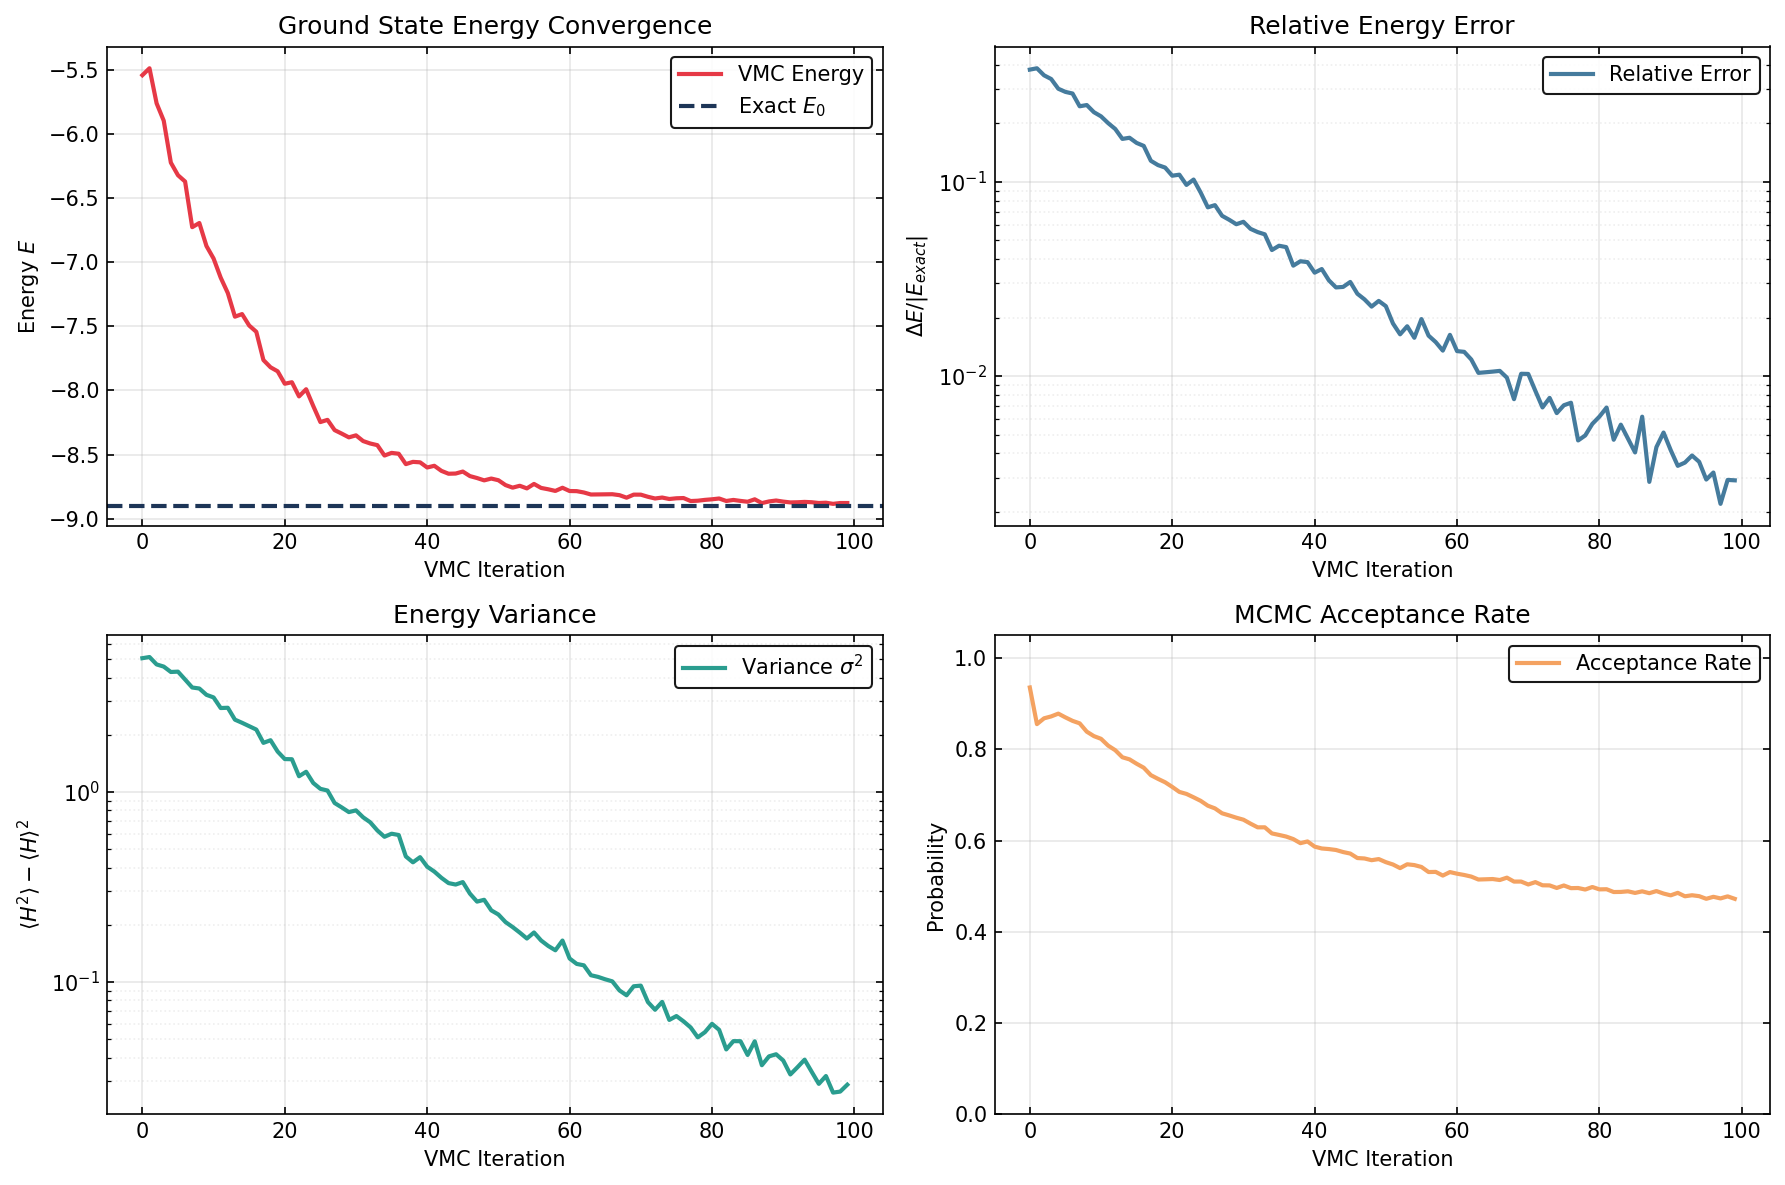

In [19]:
with open(data_file + "/VMC_datas.log") as f:
    data = json.load(f)

if verbose:
    plot_VMC(f"{data_file}/VMC_datas.log", exact_gs_energy, save_fig=True, fig_name=f"{data_file}/VMC_init_metrics.png")

In [20]:
results_eL = np.zeros(num_it)
results_e0 = np.zeros(num_it)
results_sigma_e0 = np.zeros(num_it) 
results_sigma_eL = np.zeros(num_it)
results_time = np.zeros(num_it) 

pbar = tqdm(range(num_it))

start_time_global = time.perf_counter()

for i in pbar:

    vs.sample() 
    
    el, e0, sigma_e0, sigma_eL = Krylov_method_with_bootstrap(
        vs, ha
    )

    elapsed_time = time.perf_counter() - start_time_global
    
    results_eL[i] = el
    results_e0[i] = e0
    results_sigma_e0[i] = sigma_e0
    results_sigma_eL[i] = sigma_eL
    results_time[i] = elapsed_time

    pbar.set_postfix(el=f"{el:.5f} ± {sigma_eL:.5f}", exact=f"{exact_gs_energy:.5f}")


el_valides = results_eL[~np.isnan(results_eL)]

if verbose :
    print(f"Mean of the means (E0) : {np.mean(results_e0):.8f}")
    print(f"Std of the means (E0)  : {np.std(results_e0, ddof=1):.8f}")
    print(f"Mean  (EL)             : {np.mean(el_valides):.8f}")
    print(f"Std (EL)               : {np.std(el_valides, ddof=1):.8f}")
    print(f"Exact Energy           : {exact_gs_energy}")

100%|██████████| 1000/1000 [07:43<00:00,  2.16it/s, el=-8.90528 ± 0.02407, exact=-8.90439]

Mean of the means (E0) : -8.87859250
Std of the means (E0)  : 0.00495548
Mean  (EL)             : -8.89873094
Std (EL)               : 0.00521974
Exact Energy           : -8.904386529876446


In [21]:
save_simulation_logs(
    target_dir=data_file,
    n_iterations=num_it,          
    e0_array=results_e0,      
    sigma_e0_array=results_sigma_e0, 
    el_array=results_eL,         
    sigma_el_array=results_sigma_eL,
    time_array=results_time,
    exact_energy=exact_gs_energy
)

Simulation logs successfully saved to: ../../datas/datas_krylov_iter_100/simulation_results.json


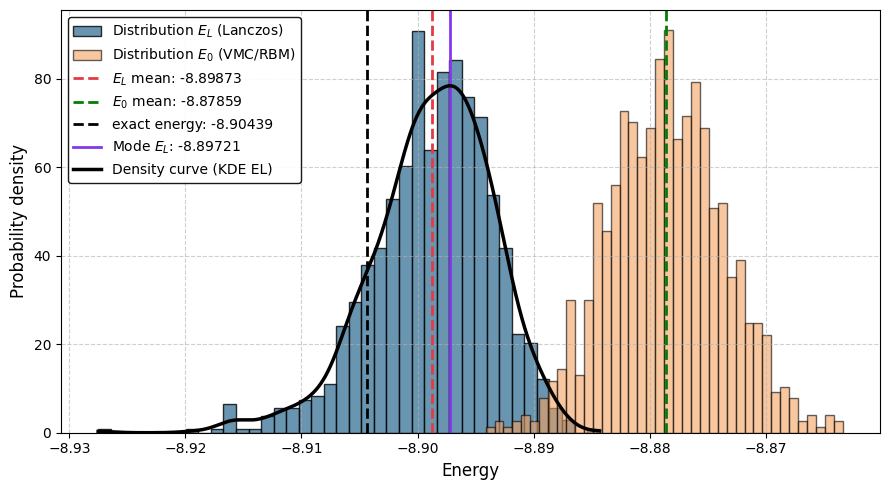

In [22]:
plot_energy_distribution(
    el_valides=el_valides, 
    results_e0=results_e0, 
    exact_gs_energy=exact_gs_energy, 
    data_file=data_file,
    bins=40 
)

Graphique d'extrapolation sauvegardé sous : ../../datas/datas_krylov_iter_100/extrapolation_plot.png


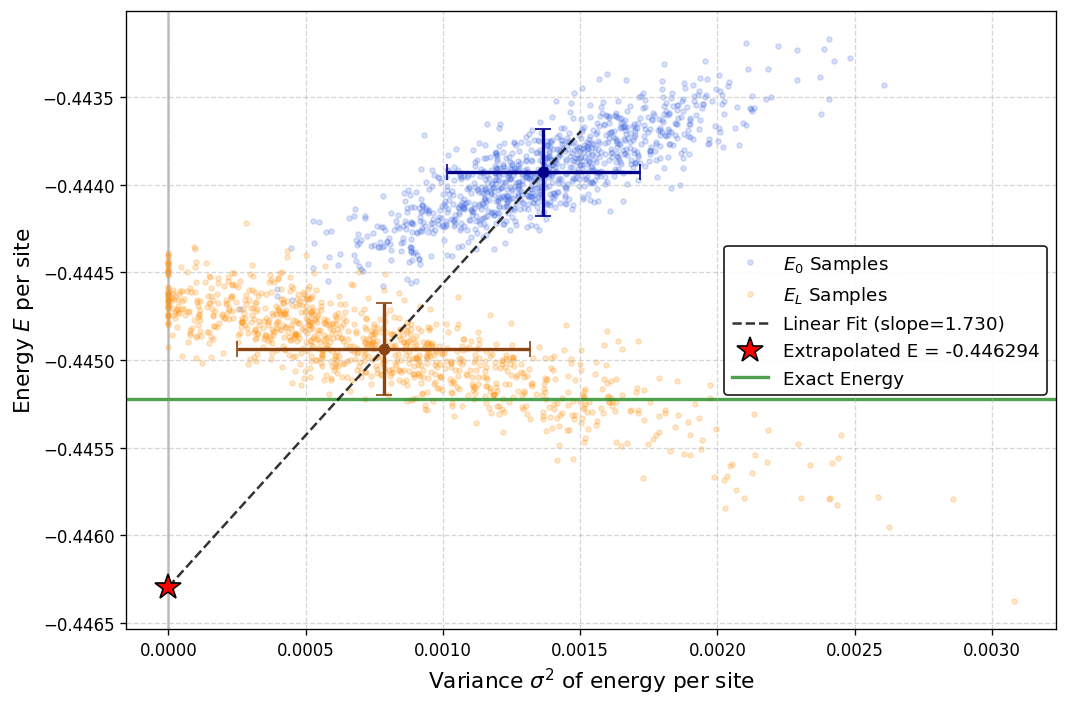


--- Extrapolation Results (per site) ---
Extrapolated Energy (x=0) : -0.44629400
Exact Energy              : -0.44521933
Absolute Error            : 1.07467370e-03
----------------------------------------



In [23]:
plot_zero_variance_extrapolation(
    results_e0 = results_e0, 
    results_sigma_e0 = results_sigma_e0, 
    el_valides = el_valides, 
    results_sigma_eL = results_sigma_eL, 
    exact_gs_energy = exact_gs_energy, 
    L = L, 
    data_file = data_file
)